# 15. New College Time-Varying IMU Calibration Experiment

This notebook follows notebook 14's New College factor-graph trajectory/calibration pipeline, but replaces the real IMU stream with an emulated stream generated from the real measured IMU values under artificial time-varying `T_B_I(t)` and `tau_I(t)` laws. LiDAR odometry remains real and unchanged. Ground-truth poses are used only for trajectory evaluation and plotting.


## 1. Configuration

All experiment controls live here. The three calibration concepts are deliberately separate: reference calibration used to interpret the real IMU stream, artificial calibration truth laws, and estimator initial guesses.


In [19]:
import numpy as np
from pathlib import Path

# Dataset and output controls.
DATASET_ROOT = Path('/mnt/d/Downloads/MobRobLab/NewCollegeDataset/01_short_experiment')
LIDAR_ODOMETRY_CSV = Path('~/Skoltech/phd_proposal/data/NewCollegeDataset/lidar_odometry.csv').expanduser()
OUTPUT_SUBDIR = 'factor_graph_new_college_time_varying_calibration'
SAVE_FIGURES = True
DIAGNOSTIC_STRIDE = 10

# Real sensor import controls.
TARGET_IMU_FREQUENCY_HZ = 100.0
MAX_IMU_FILES = None
LIDAR_SCAN_PERIOD_S = None
INVERT_IMPORTED_LIDAR_MEASUREMENTS = False
FIXED_EXTRINSIC = 'T_B_L'

# Initial-guess controls. These are estimator guesses, not artificial truth.
INITIAL_POSE_ROT_STD_RAD = 0.015
INITIAL_POSE_XY_STD_M = 0.08
INITIAL_POSE_Z_STD_M = 0.0
INITIAL_POSE_RANDOM_SEED = 7
T_B_I_ESTIMATE_INITIAL = np.eye(4)
T_B_L_ESTIMATE_INITIAL = np.eye(4)
BIAS_ESTIMATE_INITIAL = np.zeros(3)
TAU_I_ESTIMATE_INITIAL = 2.0
TAU_L_ESTIMATE_INITIAL = 0.0

# Rolling factor-graph controls. Keep close to notebook 14.
WINDOW_SIZE = 5.0
STEP_SIZE = 1.0
IMU_SAMPLES_PER_FACTOR = None
LIDAR_SAMPLES_PER_FACTOR = None
FACTOR_GRAPH_METHOD = 'LM'
ACC_MODE = 'complex'
IMU_TIME_OFFSET_MARGIN = 2.5
LIDAR_TIME_OFFSET_MARGIN = 2.5

# Artificial calibration truth controls.
# Supported modes for both laws: 'constant', 'linear', 'sinusoidal', 'piecewise'.
T_B_I_LAW_MODE = 'piecewise'
TAU_I_LAW_MODE = 'piecewise'
T_B_I_END_DELTA = np.array([
    np.deg2rad(20.0),
    np.deg2rad(-15.0),
    np.deg2rad(40.0),
    0.0,
    0.0,
    0.0,
])
T_B_I_SINUSOIDAL_AMPLITUDE = np.array([
    np.deg2rad(12.0),
    np.deg2rad(-15),
    np.deg2rad(30),
    0.0,
    0.0,
    0.0,
])
T_B_I_SINUSOIDAL_CYCLES = 1.0
T_B_I_PIECEWISE_FRACTIONS = np.array([0.0, 0.2, 0.4, 0.6, 0.8])
T_B_I_PIECEWISE_TANGENTS = np.array([
    [0.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    [np.deg2rad(25), np.deg2rad(-10), np.deg2rad(40), 0.0, 0.0, 0.0],
    [np.deg2rad(40), np.deg2rad(-20), np.deg2rad(50), 0.0, 0.0, 0.0],
    [np.deg2rad(60), np.deg2rad(-30), np.deg2rad(70), 0.0, 0.0, 0.0],
    [np.deg2rad(70), np.deg2rad(-40), np.deg2rad(100), 0.0, 0.0, 0.0],
])

TAU_I_TRUTH_START = 0.05
TAU_I_TRUTH_END = 0.5
TAU_I_SINUSOIDAL_OFFSET = 0.12
TAU_I_SINUSOIDAL_AMPLITUDE = 0.04
TAU_I_SINUSOIDAL_CYCLES = 1.0
TAU_I_PIECEWISE_FRACTIONS = np.array([0.0, 0.2, 0.4, 0.6, 0.8])
TAU_I_PIECEWISE_VALUES = np.array([0.05, 0.1, 0.18, 0.2, 0.25])

# Quasi-static IMU re-expression controls.
INCLUDE_LEVER_ARM_CORRECTION = False
ANGULAR_ACCELERATION_SMOOTHING_WINDOW = None

# Imported-data noise/linearization assumptions.
STATIONARY_SAMPLES = 1000
GYRO_NOISE_FLOOR = 1e-6
ACCEL_NOISE_FLOOR = 1e-6

# Factor-graph weights and solver settings copied from notebook 14.
TAU_I_REGULARIZATION_INFORMATION = 10
T_B_I_REGULARIZATION_INFORMATION = np.diag([1e-2, 1e-2, 1e-2, 1e1, 1e1, 1e1])
BIAS_REGULARIZATION_INFORMATION = 1
GYRO_INFORMATION = 1e0
ACCEL_INFORMATION = 1e0
LIDAR_INFORMATION_SCALE = 1e-2
SOLVER_SCHEDULER = [(1e-5, 100), (1e-5, 100), (1e-9, 100)]
GRAVITY_WORLD = (0.0, 0.0, 9.81)
ACCEL_NORM_TOLERANCE = 0.75
ACCEL_GYRO_THRESHOLD = 0.35


## 2. Imports


In [20]:
from pathlib import Path
import sys

ROOT = Path.cwd()
for candidate in (ROOT, *ROOT.parents):
    if (candidate / 'src' / 'calib_observability').exists():
        ROOT = candidate
        break
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

OUT = ROOT / 'outputs' / OUTPUT_SUBDIR
OUT.mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
from IPython.display import Image, display

import mrob
import new_college_dataset
from new_college_dataset import load_imus
from new_college_dataset.lidar import load_lidar_data_csv

import calib_observability
from calib_observability.backend import estimate_poses_dummy
from calib_observability.lie_se3 import se3_exp
from calib_observability.plotting import (
    plot_calibration_window_chi2,
    plot_imu_calibration_emulation_diagnostics,
    plot_time_varying_calibration_tracking,
    plot_trajectory_comparison,
)
from calib_observability.sensor_emulation import (
    SE3CalibrationLaw,
    ScalarCalibrationLaw,
    calibration_tracking_summary,
    emulate_time_varying_imu_calibration,
    evaluate_truth_at_window_midpoints,
)
from calib_observability.simulation import reframe_dataset_to_fixed_extrinsic
from calib_observability.workflows import build_dataset_from_imported_sensor_streams, plot_rover_dataset_overview
from factor_graph_calibration import FactorGraphCalibration

import data_processing
import transform
import utils


## 3. Real Data Import

The IMU and LiDAR streams below are the real New College streams. The later emulation step re-expresses the IMU measurements, while the LiDAR relative poses stay unchanged.


In [21]:
imu_streams = load_imus(
    DATASET_ROOT / 'raw_format' / 'realsense_imu',
    target_frequency_hz=TARGET_IMU_FREQUENCY_HZ,
    max_files=MAX_IMU_FILES,
)
primary_imu_name = list(imu_streams.keys())[0]
primary_imu = imu_streams[primary_imu_name]

lidar_data = load_lidar_data_csv(LIDAR_ODOMETRY_CSV)
velocity_timestamps = lidar_data.scan_timestamps_s if lidar_data.scan_timestamps_s is not None else lidar_data.timestamps_s
lidar_angvel_radps = transform.relative_se3_to_angvels(lidar_data.relative_poses_se3, velocity_timestamps)
lidar_velocity_mps = transform.relative_se3_to_velocities(lidar_data.relative_poses_se3, velocity_timestamps)
lidar_noise = np.hstack((
    np.std(lidar_angvel_radps[:STATIONARY_SAMPLES], axis=0),
    np.std(lidar_velocity_mps[:STATIONARY_SAMPLES], axis=0),
))

print('Primary IMU:', primary_imu_name, primary_imu.timestamps_s.shape)
print('LiDAR relative poses:', lidar_data.relative_poses_se3.shape)
print('LiDAR noise proxy:', lidar_noise)


Primary IMU: realsense_imu_data (153017,)
LiDAR relative poses: (15300, 4, 4)
LiDAR noise proxy: [0.05586253 0.05452688 0.11648389 0.33788636 0.38617523 0.11934804]


## 4. Build Notebook-14 Dataset Objects

This preserves notebook 14's imported-data construction and the fixed-`T_B_L` reframing convention.


In [22]:
T_L_OUSTER_INITIAL = np.array([[-1, 0, 0, -0.006253], [0, -1, 0, 0.011775], [0, 0, 1, -0.028535], [0, 0, 0, 1]])
T_C0_OUSTER_INITIAL = np.array([[ 0.70992163, -0.70414167,  0.01399269,  0.01562753],
                                [ 0.02460003,  0.00493623, -0.99968519, -0.01981648],
                                [ 0.70385092,  0.71004236,  0.02082624, -0.07544143],
                                [ 0.,          0.,          0.,          1.        ]])
T_C0_REALSENSE_INITIAL = np.array([[ 0.99999395,  0.00301154,  0.00174074,  0.0058566 ],
                                   [-0.00301404,  0.99999443,  0.00143592,  0.01737982],
                                   [-0.00173641, -0.00144116,  0.99999745, -0.01595566],
                                   [ 0.,          0.,          0.,          1.        ]])
T_OUSTER_REALSENSE_INITIAL = np.linalg.inv(T_C0_OUSTER_INITIAL) @ T_C0_REALSENSE_INITIAL
T_B_I_INITIAL_FOR_DATASET = T_L_OUSTER_INITIAL @ T_OUSTER_REALSENSE_INITIAL
T_B_I_INITIAL_TANGENT = mrob.SE3(T_B_I_INITIAL_FOR_DATASET).Ln()
T_B_L_INITIAL_TANGENT = np.zeros(6, dtype=float)
GYRO_BIAS_INITIAL_FOR_DATASET = np.zeros(3, dtype=float)
TAU_I_WEBSITE_REFERENCE = 0.056010849
TAU_I_NUMERICAL_REFERENCE = 0.11101
TAU_I_INITIAL_FOR_DATASET = TAU_I_NUMERICAL_REFERENCE
TAU_L_INITIAL_FOR_DATASET = 0.0

if lidar_data.scan_timestamps_s is not None and len(lidar_data.scan_timestamps_s) > 1:
    LIDAR_RATE_HZ = 1.0 / float(np.median(np.diff(lidar_data.scan_timestamps_s)))
elif len(lidar_data.timestamps_s) > 1:
    LIDAR_RATE_HZ = 1.0 / float(np.median(np.diff(lidar_data.timestamps_s)))
elif LIDAR_SCAN_PERIOD_S is not None:
    LIDAR_RATE_HZ = 1.0 / float(LIDAR_SCAN_PERIOD_S)
else:
    LIDAR_RATE_HZ = 5.0

IMPORTED_GYRO_NOISE_STD_RADPS = max(float(np.max(np.std(primary_imu.gyro_radps[:STATIONARY_SAMPLES], axis=0))), GYRO_NOISE_FLOOR)
IMPORTED_ACCEL_NOISE_STD_MPS2 = max(float(np.max(np.std(primary_imu.accel_mps2[:STATIONARY_SAMPLES], axis=0))), ACCEL_NOISE_FLOOR)
IMPORTED_LIDAR_POSE_NOISE_STD = lidar_noise

def lidar_scan_timestamps_for_pipeline(lidar_data):
    if lidar_data.scan_timestamps_s is not None:
        return np.asarray(lidar_data.scan_timestamps_s, dtype=float)
    midpoint_times = np.asarray(lidar_data.timestamps_s, dtype=float)
    if midpoint_times.size == 0:
        raise ValueError('LiDAR data has no timestamps')
    if midpoint_times.size == 1:
        if LIDAR_SCAN_PERIOD_S is None:
            raise ValueError('Set LIDAR_SCAN_PERIOD_S when only one LiDAR midpoint timestamp is available')
        half_period = 0.5 * float(LIDAR_SCAN_PERIOD_S)
        return np.array([midpoint_times[0] - half_period, midpoint_times[0] + half_period], dtype=float)
    boundaries = np.empty(midpoint_times.size + 1, dtype=float)
    boundaries[1:-1] = 0.5 * (midpoint_times[:-1] + midpoint_times[1:])
    boundaries[0] = midpoint_times[0] - (boundaries[1] - midpoint_times[0])
    boundaries[-1] = midpoint_times[-1] + (midpoint_times[-1] - boundaries[-2])
    return boundaries

lidar_scan_timestamps_s = lidar_scan_timestamps_for_pipeline(lidar_data)
raw_dataset = build_dataset_from_imported_sensor_streams(
    imu_timestamps=primary_imu.timestamps_s,
    gyroscope=primary_imu.gyro_radps,
    accelerometer=primary_imu.accel_mps2,
    lidar_scan_timestamps=lidar_scan_timestamps_s,
    lidar_relative_poses=lidar_data.relative_poses_se3,
    T_B_I_initial_tangent=T_B_I_INITIAL_TANGENT,
    T_B_L_initial_tangent=T_B_L_INITIAL_TANGENT,
    gyro_bias_initial=GYRO_BIAS_INITIAL_FOR_DATASET,
    tau_I_initial=TAU_I_INITIAL_FOR_DATASET,
    tau_L_initial=TAU_L_INITIAL_FOR_DATASET,
    gyro_noise_std=IMPORTED_GYRO_NOISE_STD_RADPS,
    accel_noise_std=IMPORTED_ACCEL_NOISE_STD_MPS2,
    lidar_pose_noise_std=IMPORTED_LIDAR_POSE_NOISE_STD,
    invert_lidar_measurements=INVERT_IMPORTED_LIDAR_MEASUREMENTS,
    true_poses_path=DATASET_ROOT / 'ground_truth/registered_poses.csv',
)
dataset = reframe_dataset_to_fixed_extrinsic(raw_dataset, FIXED_EXTRINSIC)
pose_provider = estimate_poses_dummy(dataset)

print({
    'dataset_start': dataset.start_time,
    'dataset_end': dataset.end_time,
    'imu_samples': len(dataset.imu.sensor_timestamps),
    'lidar_measurements': len(dataset.lidar.measurements),
    'fixed_extrinsic': FIXED_EXTRINSIC,
    'lidar_rate_hz_estimate': LIDAR_RATE_HZ,
})


{'dataset_start': 1583836591.182591, 'dataset_end': 1583838121.1563556, 'imu_samples': 152978, 'lidar_measurements': 15298, 'fixed_extrinsic': 'T_B_L', 'lidar_rate_hz_estimate': 9.9996280808495}


## 5. Pipeline Arrays And Reference Calibration

`T_B_I_REFERENCE` and `TAU_I_REFERENCE` are the approximately fixed real-data calibration used to reinterpret the original stream. They are not the artificial truth laws and not the estimator initial guess.


In [23]:
pose_timestamps = dataset.lidar.sensor_timestamps.copy()
true_poses = np.stack([dataset.trajectory.pose_at(float(t)) for t in pose_timestamps], axis=0)

T_B_C0 = np.array([
    [ 0.,  0.,  1., 0.],
    [-1.,  0.,  0., 0.],
    [ 0., -1.,  0., 0.],
    [ 0.,  0.,  0., 1.],
])
T_B_L_WORLD = (
    T_B_C0
    @ T_C0_OUSTER_INITIAL
    @ np.linalg.inv(T_L_OUSTER_INITIAL)
)
T_B_L_WORLD

true_timestamps, true_trajectory = new_college_dataset.data.import_true_trajectory(DATASET_ROOT / "ground_truth/registered_poses.csv")
true_trajectory = transform.transform_se3s(true_trajectory, np.linalg.inv(T_B_L_WORLD))         # B in world to B in lidar world
true_trajectory = transform.transform_se3s(true_trajectory, T_B_L_WORLD, left=False)         # B in lidar world to lidar in lidar world
true_poses = true_trajectory
pose_timestamps = true_timestamps

original_imu_timestamps = dataset.imu.sensor_timestamps.copy()
original_gyrs = dataset.imu.gyroscope.copy()
original_accs = dataset.imu.accelerometer.copy()

lidar_timestamps = dataset.lidar.sensor_timestamps.copy()
lidar_poses = np.empty((lidar_timestamps.size, 4, 4), dtype=float)
lidar_poses[0] = np.eye(4)
for measurement_index, relative_pose in enumerate(dataset.lidar.measurements):
    lidar_poses[measurement_index + 1] = lidar_poses[measurement_index] @ relative_pose

T_B_I_REFERENCE = dataset.T_B_I_true.copy()
TAU_I_REFERENCE = float(dataset.tau_I_true)
BIAS_REFERENCE = dataset.gyro_bias_true.copy()
T_B_L_REFERENCE = dataset.T_B_L_true.copy()
TAU_L_REFERENCE = float(dataset.tau_L_true)

print('reference tau_I:', TAU_I_REFERENCE)
print('reference T_B_I Ln:', mrob.SE3(T_B_I_REFERENCE).Ln())
print('estimator initial tau_I:', TAU_I_ESTIMATE_INITIAL)
print('estimator initial T_B_I Ln:', mrob.SE3(T_B_I_ESTIMATE_INITIAL).Ln())


reference tau_I: 0.11101
reference T_B_I Ln: [-0.70217089 -1.74329767  1.7650715  -0.10388228  0.04898033 -0.00375577]
estimator initial tau_I: 2.0
estimator initial T_B_I Ln: [-0.  0. -0.  0.  0.  0.]


## 6. Artificial Calibration Laws

Switch `T_B_I_LAW_MODE` or `TAU_I_LAW_MODE` in the first cell to use constant, linear, sinusoidal, or piecewise laws. The SE(3) laws use rotation-first tangents and Lie-group interpolation.


In [24]:
LAW_T_START = float(dataset.start_time)
LAW_T_END = float(dataset.end_time)
LAW_DURATION = LAW_T_END - LAW_T_START
if LAW_DURATION <= 0.0:
    raise ValueError('Dataset time span must be positive')

if T_B_I_LAW_MODE == 'constant':
    T_B_I_law = SE3CalibrationLaw('constant', reference=T_B_I_REFERENCE)
elif T_B_I_LAW_MODE == 'linear':
    T_B_I_law = SE3CalibrationLaw('linear', t_start=LAW_T_START, t_end=LAW_T_END, reference=T_B_I_REFERENCE, end_delta_xi=T_B_I_END_DELTA)
elif T_B_I_LAW_MODE == 'sinusoidal':
    T_B_I_law = SE3CalibrationLaw('sinusoidal', t_start=LAW_T_START, t_end=LAW_T_END, reference=T_B_I_REFERENCE, amplitude_xi=T_B_I_SINUSOIDAL_AMPLITUDE, cycles=T_B_I_SINUSOIDAL_CYCLES)
elif T_B_I_LAW_MODE == 'piecewise':
    T_B_I_control_times = LAW_T_START + T_B_I_PIECEWISE_FRACTIONS * LAW_DURATION
    T_B_I_law = SE3CalibrationLaw('piecewise', reference=T_B_I_REFERENCE, control_times=T_B_I_control_times, control_tangents=T_B_I_PIECEWISE_TANGENTS)
else:
    raise ValueError(f'Unsupported T_B_I_LAW_MODE: {T_B_I_LAW_MODE}')

if TAU_I_LAW_MODE == 'constant':
    tau_I_law = ScalarCalibrationLaw('constant', value=TAU_I_TRUTH_START)
elif TAU_I_LAW_MODE == 'linear':
    tau_I_law = ScalarCalibrationLaw('linear', t_start=LAW_T_START, t_end=LAW_T_END, start=TAU_I_TRUTH_START, end=TAU_I_TRUTH_END)
elif TAU_I_LAW_MODE == 'sinusoidal':
    tau_I_law = ScalarCalibrationLaw('sinusoidal', t_start=LAW_T_START, t_end=LAW_T_END, value=TAU_I_SINUSOIDAL_OFFSET, amplitude=TAU_I_SINUSOIDAL_AMPLITUDE, cycles=TAU_I_SINUSOIDAL_CYCLES)
elif TAU_I_LAW_MODE == 'piecewise':
    tau_I_control_times = LAW_T_START + TAU_I_PIECEWISE_FRACTIONS * LAW_DURATION
    tau_I_law = ScalarCalibrationLaw('piecewise', control_times=tau_I_control_times, control_values=TAU_I_PIECEWISE_VALUES)
else:
    raise ValueError(f'Unsupported TAU_I_LAW_MODE: {TAU_I_LAW_MODE}')

law_check_times = np.linspace(LAW_T_START, LAW_T_END, 5)
print('T_B_I law mode:', T_B_I_LAW_MODE)
print('T_B_I truth Ln at checks:\n', np.vstack([mrob.SE3(T).Ln() for T in T_B_I_law(law_check_times)]))
print('tau_I law mode:', TAU_I_LAW_MODE)
print('tau_I truth at checks:', tau_I_law(law_check_times))


T_B_I law mode: piecewise
T_B_I truth Ln at checks:
 [[-0.70217089 -1.74329767  1.7650715  -0.10388228  0.04898033 -0.00375577]
 [-1.06066246 -1.1967244   2.63129361 -0.08149297  0.09752024 -0.01907664]
 [ 0.86461628  0.79531456 -2.78385368  0.08389285 -0.08094101 -0.03788922]
 [ 0.68019198  0.13653453 -2.64855162  0.05128654 -0.0864397  -0.04315562]
 [ 0.6298783  -0.3697829  -2.21445835  0.01612707 -0.09015518 -0.03926694]]
tau_I law mode: piecewise
tau_I truth at checks: [0.05 0.1  0.18 0.2  0.25]


## 7. IMU Measurement Emulation

The artificial IMU stream below comes from the real measured IMU stream. The ground-truth trajectory is not used to synthesize gyro or accelerometer values. Timestamp warping follows `s_new = (s_old - tau_ref) + tau_new(s_old - tau_ref)`. The spatial re-expression is quasi-static and omits dynamics caused purely by `dot(T_B_I)`.


In [25]:
identity_emulation = emulate_time_varying_imu_calibration(
    sensor_timestamps=original_imu_timestamps,
    gyroscope=original_gyrs,
    accelerometer=original_accs,
    T_B_I_reference=T_B_I_REFERENCE,
    tau_I_reference=TAU_I_REFERENCE,
    T_B_I_law=SE3CalibrationLaw('constant', reference=T_B_I_REFERENCE),
    tau_I_law=ScalarCalibrationLaw('constant', value=TAU_I_REFERENCE),
    bias_reference=BIAS_REFERENCE,
    include_lever_arm_correction=True,
    angular_acceleration_smoothing_window=ANGULAR_ACCELERATION_SMOOTHING_WINDOW,
)
assert np.allclose(identity_emulation.sensor_timestamps, original_imu_timestamps)
assert np.allclose(identity_emulation.gyroscope, original_gyrs)
assert np.allclose(identity_emulation.accelerometer, original_accs)
print('constant-law identity regression: PASS')

emulated = emulate_time_varying_imu_calibration(
    sensor_timestamps=original_imu_timestamps,
    gyroscope=original_gyrs,
    accelerometer=original_accs,
    T_B_I_reference=T_B_I_REFERENCE,
    tau_I_reference=TAU_I_REFERENCE,
    T_B_I_law=T_B_I_law,
    tau_I_law=tau_I_law,
    bias_reference=BIAS_REFERENCE,
    include_lever_arm_correction=INCLUDE_LEVER_ARM_CORRECTION,
    angular_acceleration_smoothing_window=ANGULAR_ACCELERATION_SMOOTHING_WINDOW,
)

assert np.all(np.isfinite(emulated.sensor_timestamps))
assert np.all(np.diff(emulated.sensor_timestamps) > 0.0)
assert emulated.gyroscope.shape == original_gyrs.shape
assert emulated.accelerometer.shape == original_accs.shape
print('emulated timestamp monotonicity: PASS')
print('emulated gyroscope shape:', emulated.gyroscope.shape)
print('emulated accelerometer shape:', emulated.accelerometer.shape)
print('timestamp warp range [s]:', float(np.min(emulated.sensor_timestamps - original_imu_timestamps)), float(np.max(emulated.sensor_timestamps - original_imu_timestamps)))


constant-law identity regression: PASS
emulated timestamp monotonicity: PASS
emulated gyroscope shape: (152978, 3)
emulated accelerometer shape: (152978, 3)
timestamp warp range [s]: -0.061010122299194336 0.13898992538452148


## 8. Basic Emulation Diagnostics


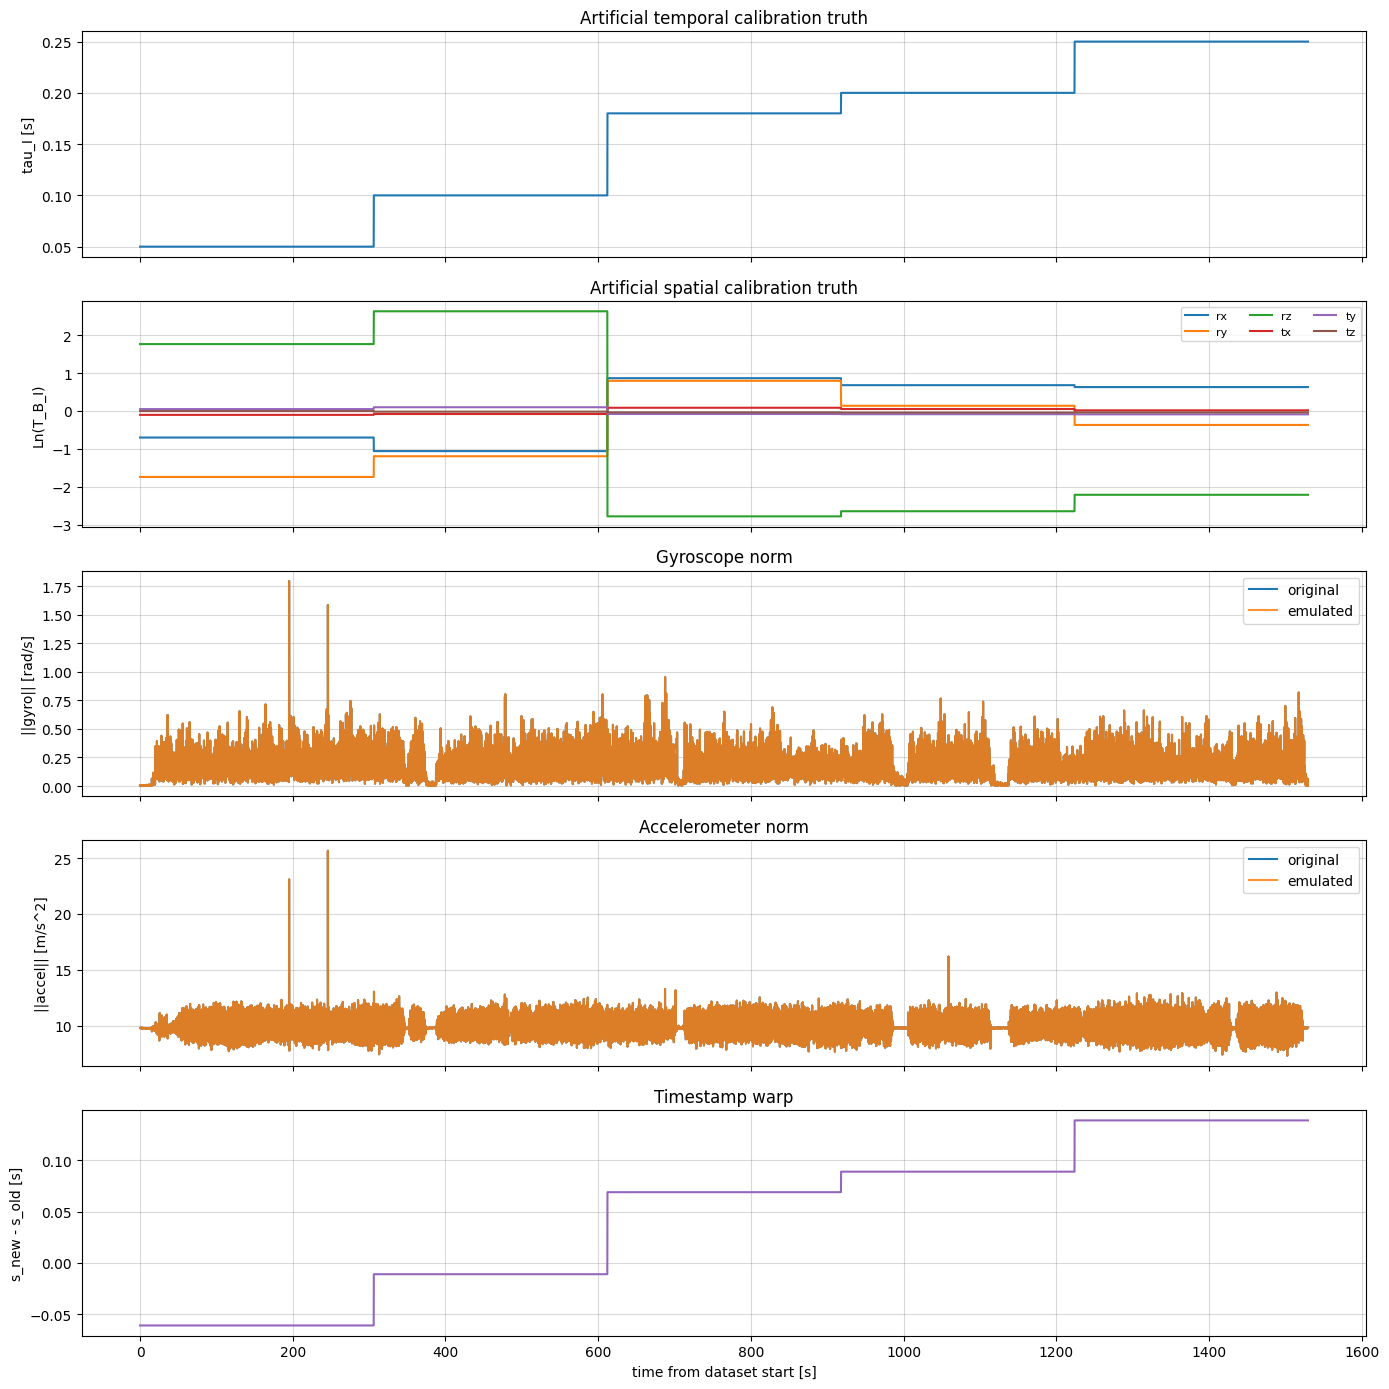

In [26]:
diag_indices = np.arange(0, original_imu_timestamps.size, max(int(DIAGNOSTIC_STRIDE), 1))
fig, axes = plot_imu_calibration_emulation_diagnostics(
    emulated.reference_timestamps[diag_indices],
    original_imu_timestamps[diag_indices],
    emulated.sensor_timestamps[diag_indices],
    original_gyrs[diag_indices],
    emulated.gyroscope[diag_indices],
    original_accs[diag_indices],
    emulated.accelerometer[diag_indices],
    emulated.T_B_I_truth[diag_indices],
    emulated.tau_I_truth[diag_indices],
)
if SAVE_FIGURES:
    fig.savefig(OUT / 'imu_emulation_diagnostics.png', dpi=160)
plt.show()
plt.close(fig)


## 9. LiDAR Trajectory Initialization

LiDAR odometry stays real and unchanged. The initial trajectory uses the same corrected `pose_timestamps[5:-5]` slice and `states=init_lidar_poses` flow as notebook 14.


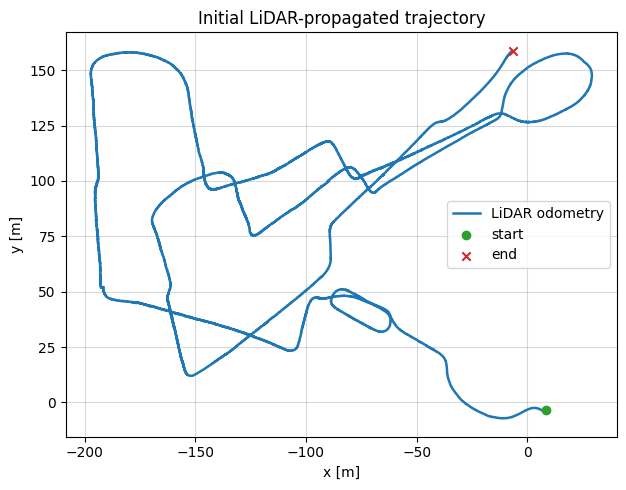

In [27]:
init_lidar_poses = data_processing._initialize_trajectory_poses(
    pose_timestamps=pose_timestamps[5:-5],
    states=[true_poses[5]],
    first_pose=true_poses[5],
    imu_timestamps=emulated.sensor_timestamps,
    angular_velocity_imu=emulated.gyroscope,
    T_B_I_initial=T_B_I_ESTIMATE_INITIAL,
    bias_initial=BIAS_ESTIMATE_INITIAL,
    tau_I_initial=TAU_I_ESTIMATE_INITIAL,
    lidar_timestamps=lidar_timestamps,
    lidar_odometry_poses=lidar_poses,
    T_B_L_initial=T_B_L_ESTIMATE_INITIAL,
    tau_L_initial=TAU_L_ESTIMATE_INITIAL,
)

fig, axis = calib_observability.plotting.plot_trajectory_2d(
    init_lidar_poses,
    title='Initial LiDAR-propagated trajectory',
    label='LiDAR odometry',
)
if SAVE_FIGURES:
    fig.savefig(OUT / 'initial_lidar_trajectory.png', dpi=160)
plt.show()
plt.close(fig)


## 10. Rolling Factor Graph


In [28]:
GYRO_INFORMATION

1.0

In [71]:
factor_graph = FactorGraphCalibration(
    imu_samples_per_factor=IMU_SAMPLES_PER_FACTOR,
    lidar_samples_per_factor=LIDAR_SAMPLES_PER_FACTOR,
    T_B_I_anchor=False,
    T_B_L_anchor=True,
    bias_anchor=False,
    tau_I_anchor=False,
    tau_L_anchor=True,
    anchor_first_pose=True,
    anchor_first_pose_each_window=True,
    anchor_last_pose=False,
    anchor_all_poses=False,
    method=FACTOR_GRAPH_METHOD,
    acc_mode=ACC_MODE,
    imu_time_offset_margin=IMU_TIME_OFFSET_MARGIN*2,
    lidar_time_offset_margin=LIDAR_TIME_OFFSET_MARGIN*2,
    tau_I_regularization_information=1e2,                                                # 1, TAU_I_REGULARIZATION_INFORMATION
    T_B_I_regularization_information=np.diag([1e1, 1e1, 1e1, 1e3, 1e3, 1e3]),        # np.diag([1e3, 1e3, 1e3, 1e3, 1e3, 1e3]), T_B_I_REGULARIZATION_INFORMATION
    bias_regularization_information=1e5,                                                  # BIAS_REGULARIZATION_INFORMATION
    solver_verbose=False,
    gyro_information=1e0,                                              # GYRO_INFORMATION
    accel_information=1e0,                                            # ACCEL_INFORMATION
    lidar_information=1e-2 * np.diag(1.0 / lidar_noise**2),      # LIDAR_INFORMATION_SCALE
    scheduler=SOLVER_SCHEDULER,
    gravity_world=GRAVITY_WORLD,
    include_gyro_factors=True,
    include_accel_factors=True,
    include_lidar_factors=True,
    accel_norm_tolerance=None,                                  # ACCEL_NORM_TOLERANCE
    accel_gyro_threshold=None,                                  # ACCEL_GYRO_THRESHOLD
    use_numerical_calibration_prior=True,
    use_numerical_calibration_initial=False,
)

results = factor_graph.generate_filter_iterative(
    window_size=WINDOW_SIZE * 10,
    step_size=WINDOW_SIZE * 10 / 2,
    pose_timestamps=pose_timestamps[5:-5],
    states=init_lidar_poses,
    imu_timestamps=emulated.sensor_timestamps,                      # identity_emulation, emulated
    angular_velocity_imu=emulated.gyroscope,
    specific_force_imu=emulated.accelerometer,
    lidar_timestamps=lidar_timestamps,
    lidar_odometry_poses=lidar_poses,
    T_B_I_initial=T_B_I_INITIAL_FOR_DATASET,                         # T_B_I_ESTIMATE_INITIAL, T_B_I_INITIAL_FOR_DATASET
    T_B_L_initial=T_B_L_ESTIMATE_INITIAL,
    bias_initial=BIAS_ESTIMATE_INITIAL,
    tau_I_initial=0,                                                 # TAU_I_ESTIMATE_INITIAL
    tau_L_initial=0,                                                 # TAU_L_ESTIMATE_INITIAL
    verbose=0,
)

estimated_timestamps, estimated_poses = factor_graph.rolling_trajectory
print(f'accelerometer mode: {ACC_MODE}')
print(f'solved windows: {len(results)}')
print(f'stitched estimated poses: {estimated_poses.shape}')
if results:
    print(f'first chi2: {results[0].chi2_before:.3e} -> {results[0].chi2_after:.3e}')
    print(f'last chi2:  {results[-1].chi2_before:.3e} -> {results[-1].chi2_after:.3e}')


accelerometer mode: complex
solved windows: 60
stitched estimated poses: (15198, 4, 4)
first chi2: 2.448e+03 -> 1.533e-01
last chi2:  8.409e+03 -> 1.876e-01


## 11. Trajectory Visualization


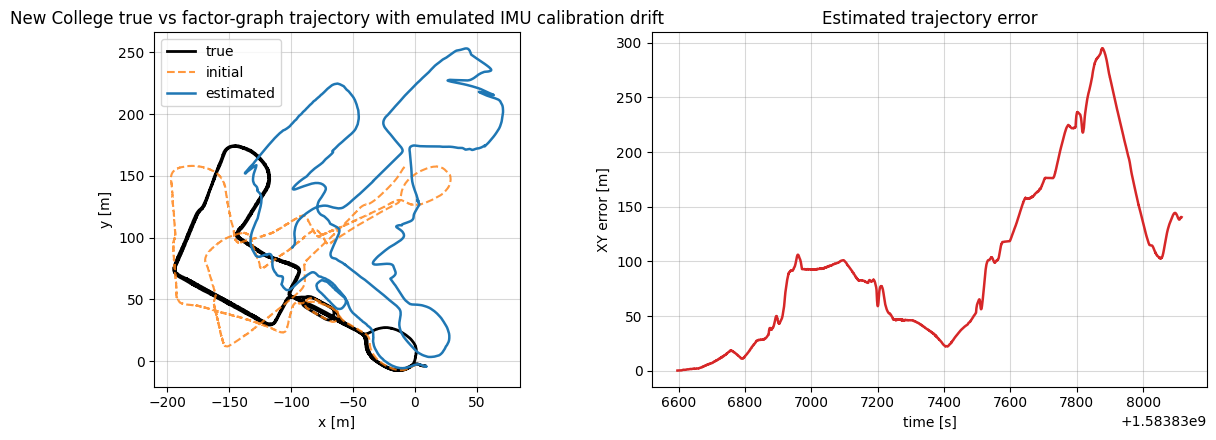

In [72]:
fig, axes = plot_trajectory_comparison(
    true_poses[5:-5],
    estimated_poses,
    true_timestamps=pose_timestamps[5:-5],
    estimated_timestamps=estimated_timestamps,
    initial_poses=init_lidar_poses,
    title='New College true vs factor-graph trajectory with emulated IMU calibration drift',
)
if SAVE_FIGURES:
    fig.savefig(OUT / 'trajectory_comparison.png', dpi=160)
plt.show()
plt.close(fig)


## 12. Window Chi2 And Summary


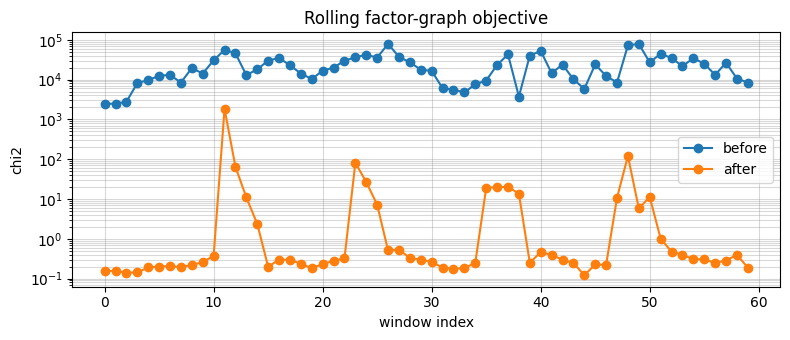

In [73]:
fig, axis = plot_calibration_window_chi2(results)
if SAVE_FIGURES:
    fig.savefig(OUT / 'rolling_window_chi2.png', dpi=160)
plt.show()
plt.close(fig)

window_midpoints, T_B_I_truth_windows, tau_I_truth_windows = evaluate_truth_at_window_midpoints(results, T_B_I_law, tau_I_law)
summary_rows = calibration_tracking_summary(
    results,
    T_B_I_truth=T_B_I_truth_windows,
    tau_I_truth=tau_I_truth_windows,
    bias_truth=BIAS_REFERENCE,
    T_B_L_truth=T_B_L_REFERENCE,
    tau_L_truth=TAU_L_REFERENCE,
)
try:
    import pandas as pd
    summary_table = pd.DataFrame(summary_rows)
    # display(summary_table)
except ImportError:
    summary_rows[:5]


## 13. Time-Varying Calibration Truth Vs Estimates

`T_B_I` and `tau_I` truth are evaluated at rolling-window midpoints. `T_B_L`, `tau_L`, and bias are still compared to their unchanged references.


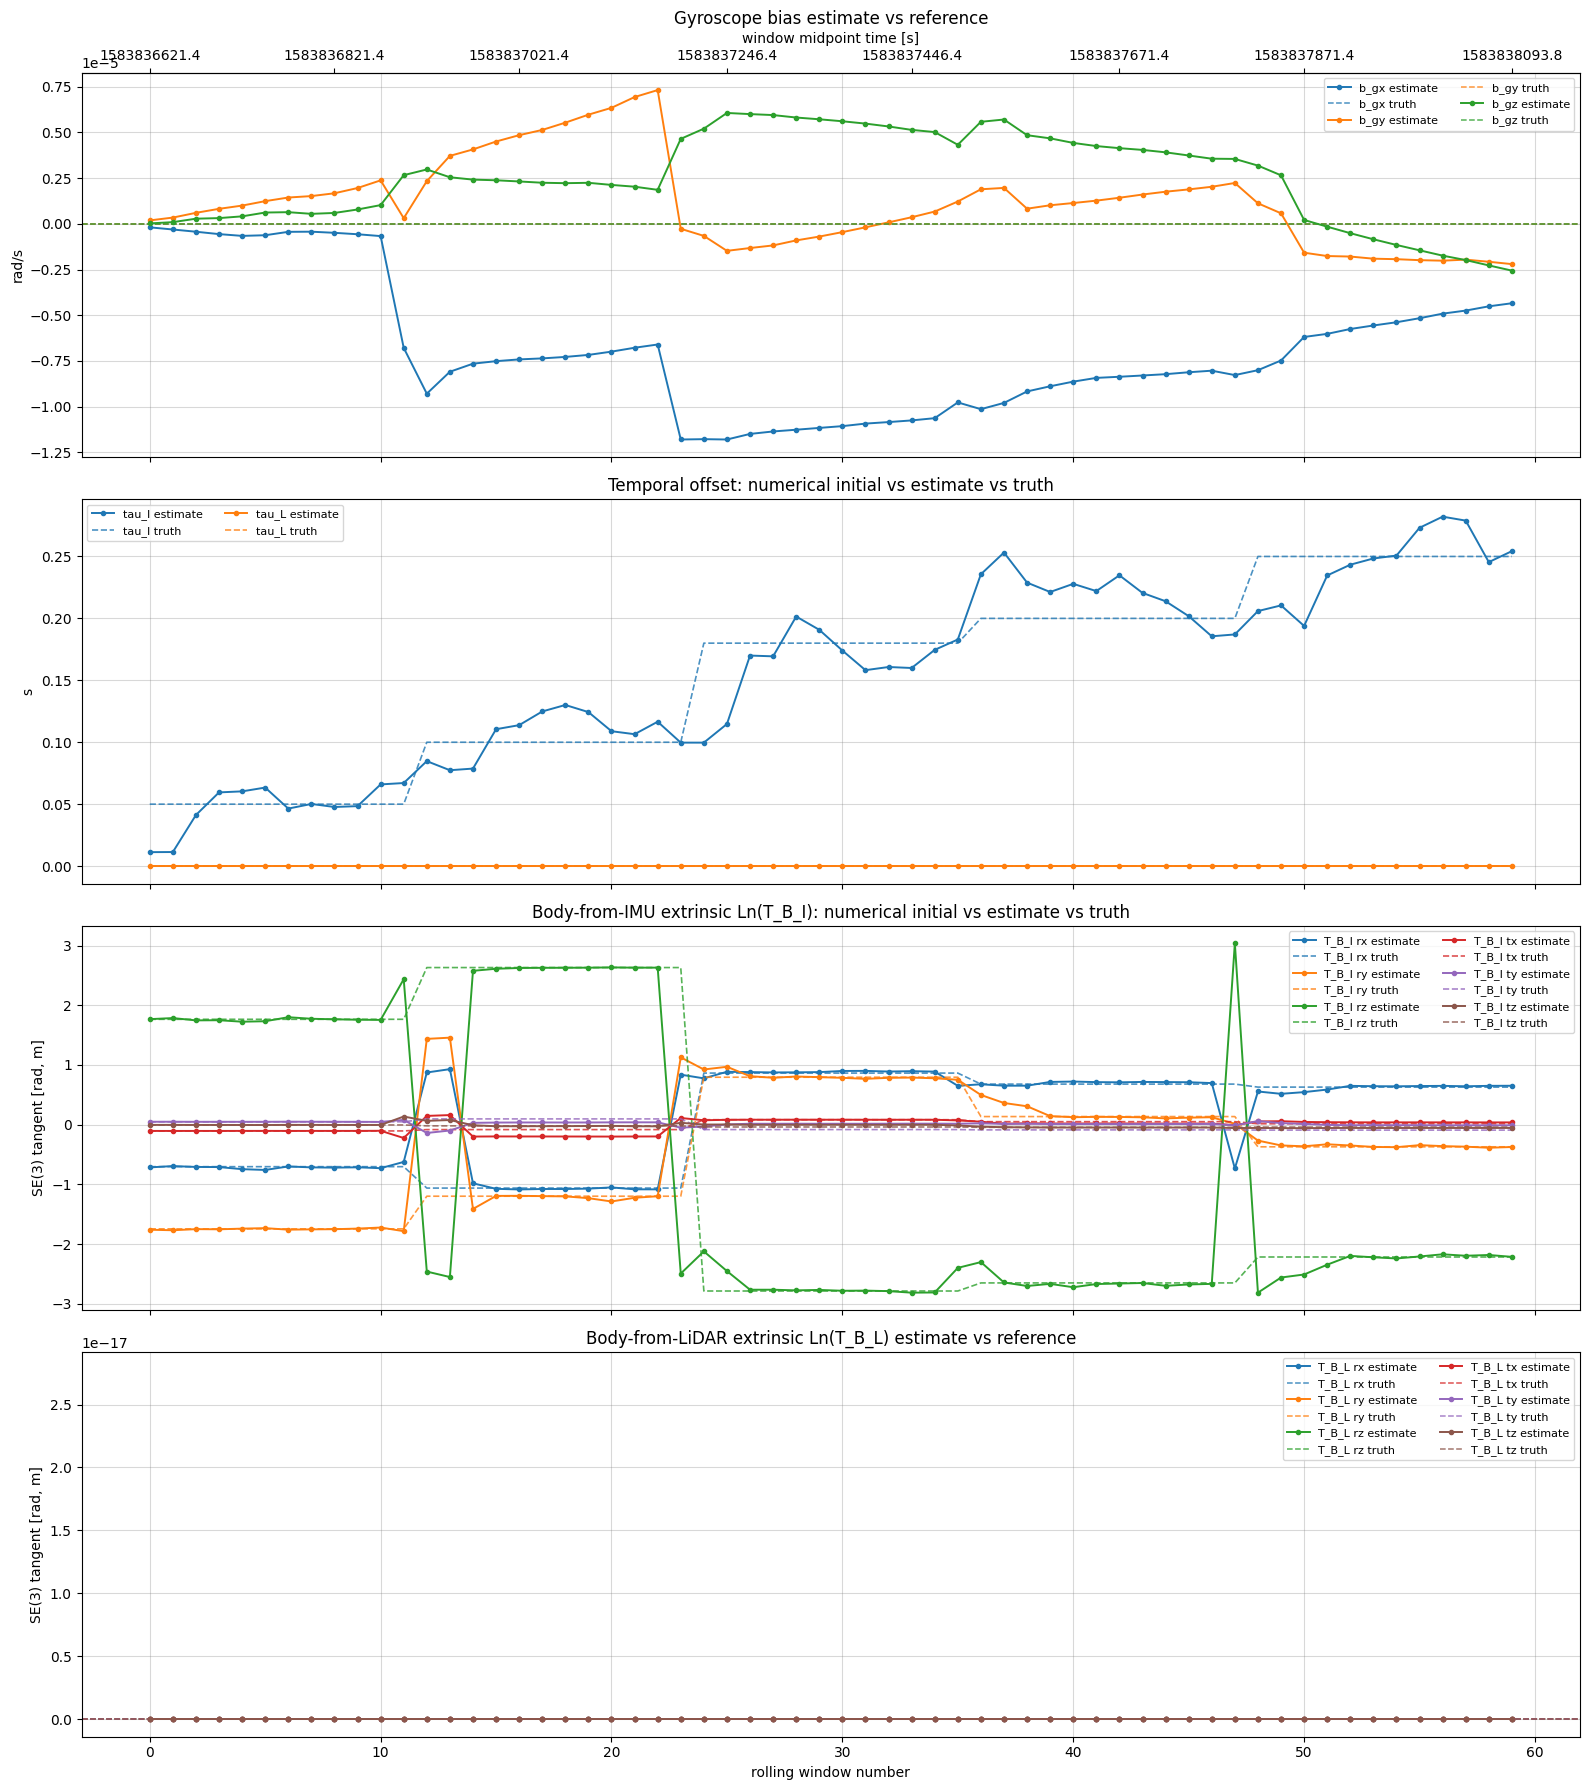

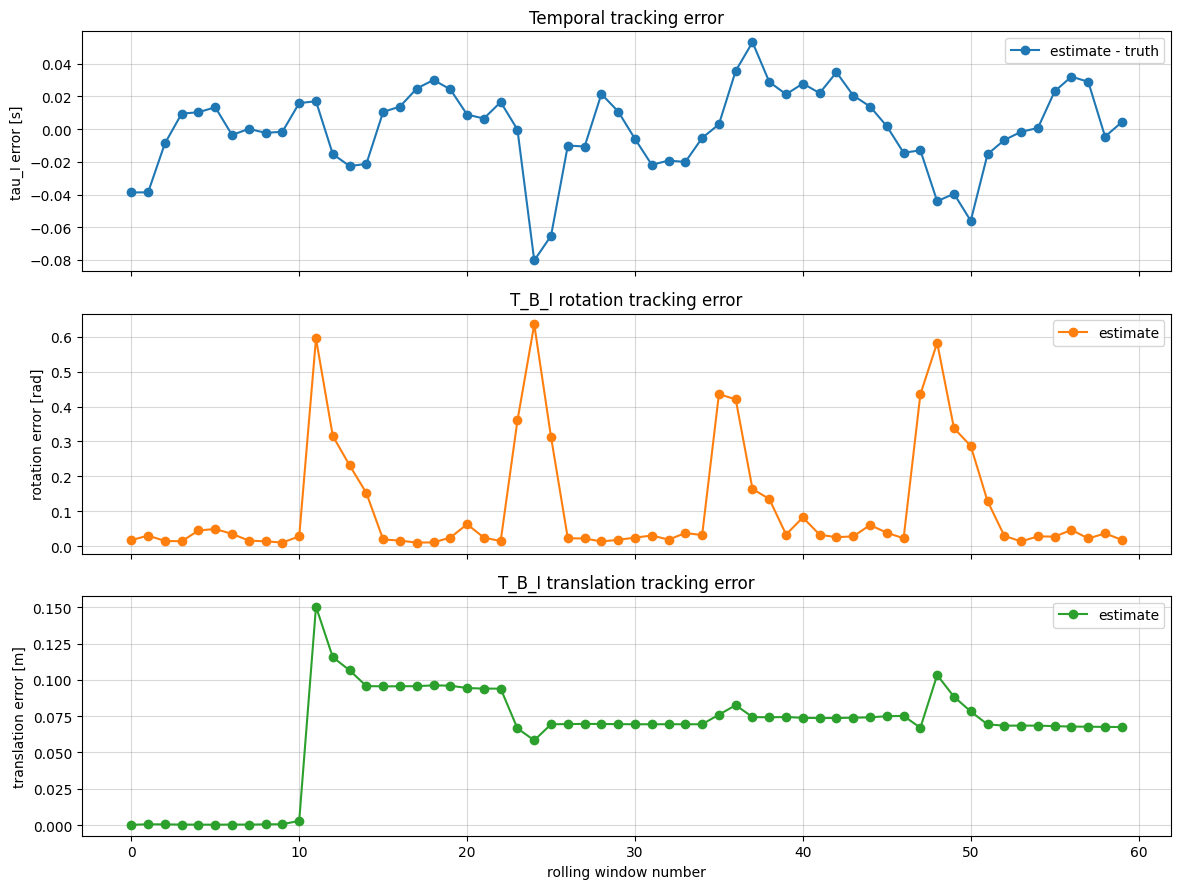

In [74]:
fig, axes, error_fig, error_axes = plot_time_varying_calibration_tracking(
    results,
    T_B_I_truth=T_B_I_truth_windows,
    tau_I_truth=tau_I_truth_windows,
    bias_truth=BIAS_REFERENCE,
    T_B_L_truth=T_B_L_REFERENCE,
    tau_L_truth=TAU_L_REFERENCE,
)
if SAVE_FIGURES:
    fig.savefig(OUT / 'rolling_calibration_estimates_vs_time_varying_truth.png', dpi=160)
    error_fig.savefig(OUT / 'rolling_calibration_tracking_errors.png', dpi=160)
plt.show()
plt.close(fig)
plt.show()
plt.close(error_fig)


## 14. Modelling Notes

- Artificial IMU measurements originate from the real New College measured IMU stream.
- Ground-truth trajectory poses are not used to synthesize gyroscope or accelerometer samples.
- The calibration drift emulator is quasi-static by default: `T_B_I(t)` is a slowly changing calibration parameter.
- Dynamics caused purely by motion of the mounting transform itself, such as `dot(T_B_I)`, relative joint angular velocity, `r_dot`, and `r_ddot`, are intentionally omitted because the current factor graph estimates one constant calibration per rolling window.
- Time-varying `tau_I` is implemented by timestamp warping with the existing factor convention `s_new = (s_old - tau_ref) + tau_new(s_old - tau_ref)`.
- Choose drift laws slow relative to the rolling-window duration for primary experiments.
